In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [2]:
df=pd.read_csv('/mnt/home/monkhayd/Simulations/Ejection_modeling/Mass_Fraction/Outputs/Ejection_Results/11828303_ejection_results.txt', header=None)

In [3]:
df.columns=['mass','result','tmax']

In [4]:
df

,mass,result,tmax
0,0.000712,1,0.000000
1,0.000712,1,0.000000
2,0.000712,1,0.000000
3,0.000712,1,0.000000
4,0.000712,1,0.000000
...,...,...,...
2999906,0.000712,1,750000.000000
2999907,0.000712,1,727272.727273
2999908,0.000712,1,734848.484848
2999909,0.000712,1,742424.242424


In [5]:
grouped = (
    df.groupby(["mass", "tmax"])
      .agg(
          total_particles=("result", "size"),
          ejected_particles=("result", lambda x: (x == 0).sum())
      )
      .reset_index()
)

grouped["ejection_fraction"] = (
    grouped["ejected_particles"] / grouped["total_particles"]
)

In [6]:
grouped['delta_f'] = grouped['ejection_fraction']-grouped['ejection_fraction'].shift(1)

In [7]:
peak_time_by_mass = (
    grouped.loc[grouped.groupby("mass")["delta_f"].idxmax()]
           .set_index("mass")["tmax"]
)

In [8]:
peak_time_by_mass*15

mass
0.000300    4.121212e+06
0.000712    7.954545e+05
0.001689    2.363636e+05
0.004004    1.000000e+05
0.009496    5.545455e+04
Name: tmax, dtype: float64

In [9]:
def tremaine_scaling(t, a):
    return a * t**(-2)

def morrison_scaling(t, a):
    return a * t**(-1.5)

In [10]:
a_tremaine, pcov_tremaine = curve_fit(tremaine_scaling, peak_time_by_mass.index, peak_time_by_mass.values)
a_morrison, pcov_morrison = curve_fit(morrison_scaling, peak_time_by_mass.index, peak_time_by_mass.values)

In [11]:

t_values = np.linspace(0, 1.5e-2, 100)
fitted_values_tremaine = tremaine_scaling(t_values, a_tremaine)
fitted_values_morrison = morrison_scaling(t_values, a_morrison)

/tmp/ipykernel_1364328/2326761312.py:2: RuntimeWarning: divide by zero encountered in power
  return a * t**(-2)
/tmp/ipykernel_1364328/2326761312.py:5: RuntimeWarning: divide by zero encountered in power
  return a * t**(-1.5)


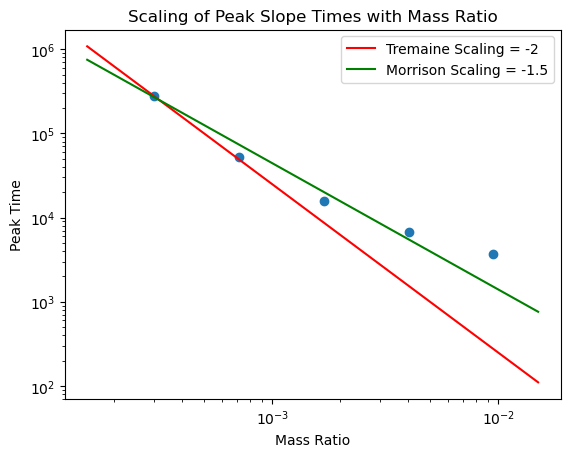

In [24]:
plt.scatter(peak_time_by_mass.index, peak_time_by_mass.values)
plt.plot(t_values, fitted_values_tremaine, color='red', label='Tremaine Scaling = -2')
plt.plot(t_values, fitted_values_morrison, color='green', label='Morrison Scaling = -1.5')
plt.xlabel('Mass Ratio')
plt.ylabel('Peak Time')
plt.legend()
plt.title('Scaling of Peak Slope Times with Mass Ratio')
plt.yscale('log')
plt.xscale('log')
#plt.savefig('/mnt/home/monkhayd/Simulations/Ejection_modeling/Mass_Fraction/Outputs/Visualizations/peak_time_scaling.png')

In [13]:
fitted_peak_times_tremaine = tremaine_scaling(peak_time_by_mass.index, a_tremaine)
fitted_peak_times_morrison = morrison_scaling(peak_time_by_mass.index, a_morrison)

In [14]:
rmse_tremaine = np.sqrt(np.mean((peak_time_by_mass.values - fitted_peak_times_tremaine)**2))
rmse_morrison = np.sqrt(np.mean((peak_time_by_mass.values - fitted_peak_times_morrison)**2))

In [15]:
print(rmse_tremaine, rmse_morrison)

4568.921617212428 9841.135740895392


In [16]:
for mass in peak_time_by_mass.index:
    print(1.3*mass**(2/7), (mass/(3))**(1/3))
    

0.12809087531727056 0.04642980892728615
0.16393148687992462 0.06191536608048004
0.20979986704283463 0.08256546176701249
0.26850258752923456 0.11010293395118273
0.3436301851012843 0.14682461175814382


In [17]:

grouped["scaled_time"] = (
    grouped["tmax"]
    / grouped["mass"].map(peak_time_by_mass)
)

In [18]:
grouped

,mass,tmax,total_particles,ejected_particles,ejection_fraction,delta_f,scaled_time
0,0.000300,0.000000,6000,0,0.000000,NaN,0.000000
1,0.000300,34343.434343,6000,0,0.000000,0.000000,0.125000
2,0.000300,68686.868687,6000,20,0.003333,0.003333,0.250000
3,0.000300,103030.303030,6000,103,0.017167,0.013833,0.375000
4,0.000300,137373.737374,6000,275,0.045833,0.028667,0.500000
...,...,...,...,...,...,...,...
495,0.009496,58535.353535,6000,3650,0.608333,0.000000,15.833333
496,0.009496,59151.515152,6000,3650,0.608333,0.000000,16.000000
497,0.009496,59767.676768,6000,3651,0.608500,0.000167,16.166667
498,0.009496,60383.838384,6000,3653,0.608833,0.000333,16.333333


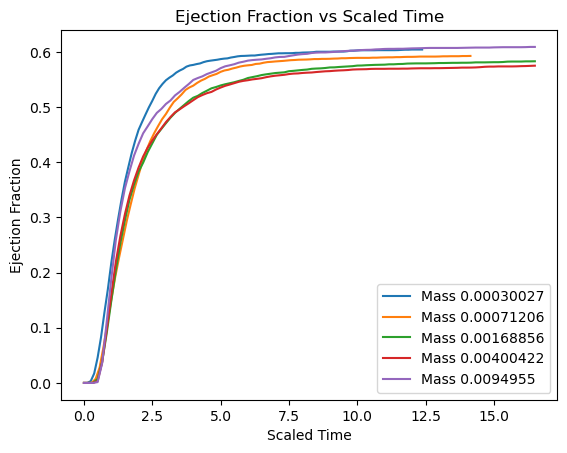

In [19]:
masses = np.sort(grouped["mass"].unique())
for mass in masses:
    plt.plot(
        grouped.loc[grouped["mass"] == mass, "scaled_time"],
        grouped.loc[grouped["mass"] == mass, "ejection_fraction"],
        label=f"Mass {mass}",
    )
plt.xlabel("Scaled Time")
plt.ylabel("Ejection Fraction")
plt.title("Ejection Fraction vs Scaled Time")
plt.legend()
plt.show()

In [20]:
grouped_max_m=grouped[grouped.mass==grouped.iloc[499].mass]

In [21]:
grouped_max_m


,mass,tmax,total_particles,ejected_particles,ejection_fraction,delta_f,scaled_time
400,0.009496,0.000000,6000,0,0.000000,-0.574833,0.000000
401,0.009496,616.161616,6000,0,0.000000,0.000000,0.166667
402,0.009496,1232.323232,6000,0,0.000000,0.000000,0.333333
403,0.009496,1848.484848,6000,9,0.001500,0.001500,0.500000
404,0.009496,2464.646465,6000,216,0.036000,0.034500,0.666667
...,...,...,...,...,...,...,...
495,0.009496,58535.353535,6000,3650,0.608333,0.000000,15.833333
496,0.009496,59151.515152,6000,3650,0.608333,0.000000,16.000000
497,0.009496,59767.676768,6000,3651,0.608500,0.000167,16.166667
498,0.009496,60383.838384,6000,3653,0.608833,0.000333,16.333333


In [22]:
grouped.groupby('mass')['delta_f'].idxmax()

mass
0.000300      8
0.000712    107
0.001689    206
0.004004    306
0.009496    406
Name: delta_f, dtype: int64

In [23]:
grouped['scaled_time']=grouped.groupby('mass')['tmax']

ValueError: Length of values (5) does not match length of index (500)

for x in grouped.delta_f:
    print(x)

In [ ]:
grouped['mass'].unique()

array([0.00030027, 0.00071206, 0.00168856, 0.00400422, 0.0094955 ])

In [ ]:
grouped[grouped.mass==grouped['mass'].iloc[79]]

,mass,tmax,total_particles,ejected_particles,ejection_fraction,delta_f
0,0.0003,0.000000e+00,6000,0,0.000000,NaN
1,0.0003,2.020202e+04,6000,0,0.000000,0.000000
2,0.0003,4.040404e+04,6000,0,0.000000,0.000000
3,0.0003,6.060606e+04,6000,4,0.000667,0.000667
4,0.0003,8.080808e+04,6000,25,0.004167,0.003500
...,...,...,...,...,...,...
95,0.0003,1.919192e+06,5999,3499,0.583264,0.000167
96,0.0003,1.939394e+06,5999,3499,0.583264,0.000000
97,0.0003,1.959596e+06,5999,3502,0.583764,0.000500
98,0.0003,1.979798e+06,5999,3502,0.583764,0.000000


In [ ]:



def logistic(t, F0, Finf, k, t0):
    return F0 + (Finf - F0) / (1.0 + np.exp(-k * (t - t0)))

def generalized_logistic(t, F0, Finf, k, t0, nu):
    return F0 + (Finf - F0) / (
        1.0 + np.exp(-k * (t - t0))
    )**(1.0 / nu)

def gompertz(t, F0, Finf, k, t0):
    return F0 + (Finf - F0) * np.exp(
        -np.exp(-k * (t - t0))
    )

def stretched_exponential(t, Finf, A, tau, beta):
    return Finf - A * np.exp(-(t / tau)**beta)

def power_law_tail(t, Finf, A, tc, p):
    return Finf - A * (t + tc)**(-p)

In [ ]:
def fit_one_mass(group, time_col="tmax", fraction_col="ejection_fraction"):
    group = (
        group[[time_col, fraction_col]]
        .dropna()
        .sort_values(time_col)
    )

    t = group[time_col].to_numpy(dtype=float)
    F = group[fraction_col].to_numpy(dtype=float)

    if len(t) < 6:
        raise ValueError("Not enough time points to fit five parameters.")

    if np.ptp(t) == 0:
        raise ValueError("All time values are identical.")

    F0_guess = F[0]
    Finf_guess = min(1.0, max(F.max() + 0.02, F.max()))
    k_guess = 1.0 / np.ptp(t)
    t0_guess = t[np.argmin(np.abs(F - 0.5 * (F.min() + F.max())))]
    nu_guess = 1.0

    p0 = [
        F0_guess,
        Finf_guess,
        k_guess,
        t0_guess,
     #   nu_guess
    ]

    # Finf is constrained to be at least as large as the largest
    # observed ejection fraction and no larger than 1.
    lower_bounds = [
    0.0,       # F0
    F.max(),   # Finf
    0.0,       # k
    t.min(),   # t0
 #   0.05       # nu
    ]

    upper_bounds = [
        1.0,       # F0
        1.0,       # Finf
        np.inf,    # k
        t.max(),   # t0
 #       20.0       # nu
    ]

    popt, pcov = curve_fit(
        logistic,
        t,
        F,
        p0=p0,
        bounds=(lower_bounds, upper_bounds),
        maxfev=100_000
    )

    perr = np.sqrt(np.diag(pcov))

    return {
        "parameters": popt,
        "parameter_errors": perr,
        "covariance": pcov,
        "time": t,
        "fraction": F
    }

In [ ]:
mass_col = "mass"
time_col = "tmax"
fraction_col = "ejection_fraction"

fit_results = {}
parameter_rows = []

for mass, group in grouped.groupby(mass_col, sort=True):
    try:
        result = fit_one_mass(
            group,
            time_col=time_col,
            fraction_col=fraction_col
        )

        fit_results[mass] = result

        popt = result["parameters"]
        perr = result["parameter_errors"]

        parameter_rows.append({
            mass_col: mass,

            "F0": popt[0],
            "F0_error": perr[0],

            "F_inf": popt[1],
            "F_inf_error": perr[1],

            "k": popt[2],
            "k_error": perr[2],

            "t0": popt[3],
            "t0_error": perr[3],

            # "nu": popt[4],
            # "nu_error": perr[4],

            "fit_success": True,
            "error_message": ""
        })

    except (RuntimeError, ValueError) as error:
        parameter_rows.append({
            mass_col: mass,
            "F0": np.nan,
            "F0_error": np.nan,
            "F_inf": np.nan,
            "F_inf_error": np.nan,
            "k": np.nan,
            "k_error": np.nan,
            "t0": np.nan,
            "t0_error": np.nan,
            "nu": np.nan,
            "nu_error": np.nan,
            "fit_success": False,
            "error_message": str(error)
        })


fit_parameters = pd.DataFrame(parameter_rows)

In [ ]:
fit_parameters

,mass,F0,F0_error,F_inf,F_inf_error,k,k_error,t0,t0_error,fit_success,error_message
0,0.000300,1.026371e-10,0.541293,0.603764,0.082656,0.000002,0.000002,343434.343434,912139.274548,True,
1,0.000712,7.936321e-15,0.020394,0.594599,0.002608,0.000028,0.000002,91074.272989,3536.208216,True,
2,0.001689,4.632291e-10,0.709295,0.590333,0.094057,0.000020,0.000021,22323.232323,109902.716870,True,
3,0.004004,1.829034e-21,0.030210,0.573500,0.003213,0.000225,0.000022,11118.923082,678.212129,True,
4,0.009496,1.421675e-01,0.489598,0.620239,0.012827,0.000083,0.000047,4173.289361,24086.883969,True,


In [ ]:
t = grouped["tmax"].to_numpy(dtype=float)
F = grouped["ejection_fraction"].to_numpy(dtype=float)

p0 = [
    F[0],             # F0
    min(1.0, F[-1] + 0.05),  # Finf
    1.0 / np.ptp(t), # k
    np.median(t),     # t0
 #   1.0               # nu
]

bounds = (
    [0.0, F.max(), 0.0, t.min()],
    [1.0, 1.0, np.inf, t.max()]
)

popt, pcov = curve_fit(
    logistic,
    t,
    F,
    p0=p0,
    bounds=bounds,
    maxfev=100_000
)

perr = np.sqrt(np.diag(pcov))

F0_fit, Finf_fit, k_fit, t0_fit = popt
Finf_error = perr[1]

print("Asymptote:", Finf_fit)
print("Approximate 1-sigma fit uncertainty:", Finf_error)

Asymptote: 0.6120947581658196
Approximate 1-sigma fit uncertainty: 0.5206512486612136


In [ ]:
fit_parameters.iloc[0]

mass                    0.0003
F0                         0.0
F0_error              0.541293
F_inf                 0.603764
F_inf_error           0.082656
k                     0.000002
k_error               0.000002
t0               343434.343434
t0_error         912139.274548
fit_success               True
error_message                 
Name: 0, dtype: object

In [ ]:
time_array=np.linspace(0,2000_000,1000)

In [ ]:
m0_fit_curve=logistic(time_array, fit_parameters.iloc[0].F0, fit_parameters.iloc[0].F_inf, fit_parameters.iloc[0].k, fit_parameters.iloc[0].t0)

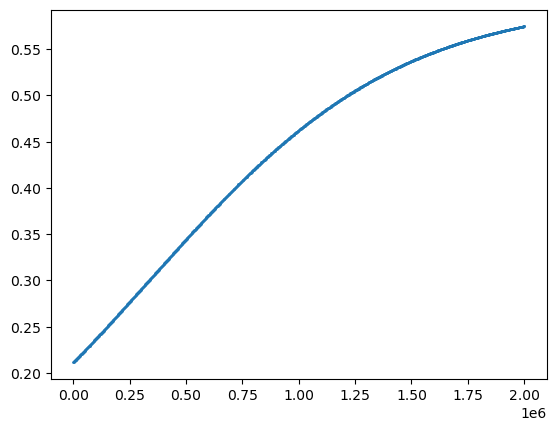

In [ ]:
plt.scatter(time_array, m0_fit_curve, s=1)

In [ ]:
curve_fit?

Signature:
curve_fit(
    f,
    xdata,
    ydata,
    p0=None,
    sigma=None,
    absolute_sigma=False,
    check_finite=None,
    bounds=(-inf, inf),
    method=None,
    jac=None,
    *,
    full_output=False,
    nan_policy=None,
    **kwargs,
)
Docstring:
Use non-linear least squares to fit a function, f, to data.

Assumes ``ydata = f(xdata, *params) + eps``.

Parameters
----------
f : callable
    The model function, f(x, ...). It must take the independent
    variable as the first argument and the parameters to fit as
    separate remaining arguments.
xdata : array_like
    The independent variable where the data is measured.
    Should usually be an M-length sequence or an (k,M)-shaped array for
    functions with k predictors, and each element should be float
    convertible if it is an array like object.
ydata : array_like
    The dependent data, a length M array - nominally ``f(xdata, ...)``.
p0 : array_like, optional
    Initial guess for the parameters (length N). If None

In [ ]:
grouped_m1=grouped[grouped.mass==grouped['mass'].iloc[0]]

In [ ]:
grouped_m1

,mass,tmax,total_particles,ejected_particles,ejection_fraction,delta_f
0,0.0003,0.000000e+00,6000,0,0.000000,NaN
1,0.0003,2.020202e+04,6000,0,0.000000,0.000000
2,0.0003,4.040404e+04,6000,0,0.000000,0.000000
3,0.0003,6.060606e+04,6000,4,0.000667,0.000667
4,0.0003,8.080808e+04,6000,25,0.004167,0.003500
...,...,...,...,...,...,...
95,0.0003,1.919192e+06,5999,3499,0.583264,0.000167
96,0.0003,1.939394e+06,5999,3499,0.583264,0.000000
97,0.0003,1.959596e+06,5999,3502,0.583764,0.000500
98,0.0003,1.979798e+06,5999,3502,0.583764,0.000000


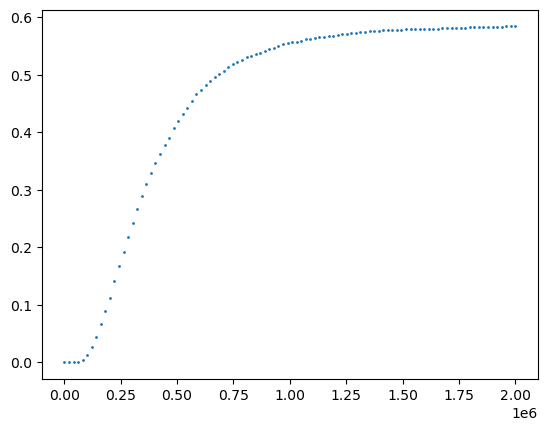

In [ ]:
plt.scatter(grouped_m1.tmax, grouped_m1.ejection_fraction, s=1)

In [ ]:
cf_result=curve_fit(gompertz, grouped_m1.tmax, grouped_m1.ejection_fraction, p0=[0.0, 0.6, 1e-6, 0.0])

In [ ]:
popt, pcov=cf_result
F0, Finf, k, t0=popt
m1_fit_curve=logistic(time_array, F0, Finf, k, t0)

In [ ]:
popt

array([-3.82953578e-02,  5.76786392e-01,  4.96629241e-06,  2.62305116e+05])

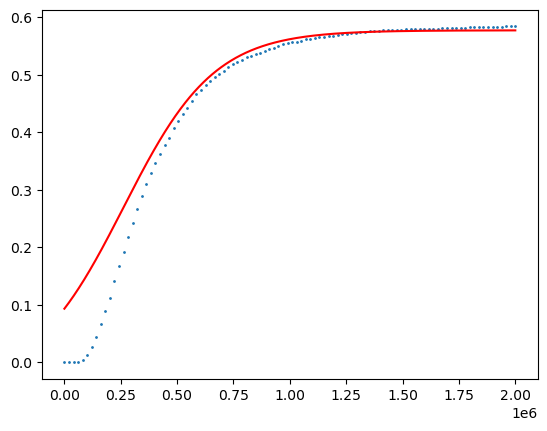

In [ ]:
plt.plot(time_array, m1_fit_curve, color='red', label='Fitted Curve')
plt.scatter(grouped_m1.tmax, grouped_m1.ejection_fraction, s=1)